# 71 Unified comparison: main models + challengers

Build one comparison table across all currently available models.

Goals:
- keep `main` and `challenger` rows together in one table;
- place models from the same family next to each other;
- compare them on the shared metrics: accuracy, macro-F1, worst gap, macro gap;
- attach city-swap results when available;
- produce a compact text summary for thesis writing.


In [26]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None


In [27]:
CWD = Path.cwd().resolve()
NOTEBOOKS_DIR = CWD.parent if CWD.name == 'challengers' else CWD
PROJECT_ROOT = NOTEBOOKS_DIR.parent
NOTEBOOK_RESULTS_DIR = PROJECT_ROOT / 'notebooks' / 'results'
FIGURES_DIR = PROJECT_ROOT / 'figures'
CHALLENGER_FIGURES_DIR = FIGURES_DIR / 'challengers'
OUTPUT_DIR = NOTEBOOK_RESULTS_DIR / 'unified_comparison'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAIN_CITY_SWAP_JSON_CANDIDATES = [
    NOTEBOOK_RESULTS_DIR / 'city_swap_all' / 'city_swap_all_models.json',
    FIGURES_DIR / 'city_swap_all' / 'city_swap_all_models.json',
    PROJECT_ROOT / 'results' / 'city_swap_all' / 'city_swap_all_models.json',
]
CHALLENGER_OVERVIEW_CSV = CHALLENGER_FIGURES_DIR / 'c00_all_models_overview.csv'
CHALLENGER_CITY_SWAP_RUN_CANDIDATES = [
    NOTEBOOK_RESULTS_DIR / 'challengers_city_swap' / 'c10_city_swap_run_level.csv',
    CHALLENGER_FIGURES_DIR / 'c10_city_swap_run_level.csv',
    PROJECT_ROOT / 'results' / 'challengers_city_swap' / 'c10_city_swap_run_level.csv',
]
CHALLENGER_CITY_SWAP_FAMILY_CANDIDATES = [
    NOTEBOOK_RESULTS_DIR / 'challengers_city_swap' / 'c10_city_swap_family_level.csv',
    CHALLENGER_FIGURES_DIR / 'c10_city_swap_family_level.csv',
    PROJECT_ROOT / 'results' / 'challengers_city_swap' / 'c10_city_swap_family_level.csv',
]
TEXT_REPORT = OUTPUT_DIR / 'c71_unified_models_report.txt'
TABLE_CSV = OUTPUT_DIR / 'c71_unified_models_table.csv'
FAMILY_CSV = OUTPUT_DIR / 'c71_family_summary.csv'
PLOT_PATH = OUTPUT_DIR / 'c71_accuracy_vs_gap.png'

def first_existing(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    return None

MAIN_CITY_SWAP_JSON = first_existing(MAIN_CITY_SWAP_JSON_CANDIDATES)
CHALLENGER_CITY_SWAP_RUN_CSV = first_existing(CHALLENGER_CITY_SWAP_RUN_CANDIDATES)
CHALLENGER_CITY_SWAP_FAMILY_CSV = first_existing(CHALLENGER_CITY_SWAP_FAMILY_CANDIDATES)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('MAIN_CITY_SWAP_JSON:', MAIN_CITY_SWAP_JSON)
print('CHALLENGER_OVERVIEW_CSV exists:', CHALLENGER_OVERVIEW_CSV.exists())
print('CHALLENGER_CITY_SWAP_RUN_CSV:', CHALLENGER_CITY_SWAP_RUN_CSV)
print('CHALLENGER_CITY_SWAP_FAMILY_CSV:', CHALLENGER_CITY_SWAP_FAMILY_CSV)
print('OUTPUT_DIR:', OUTPUT_DIR)


PROJECT_ROOT: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository
MAIN_CITY_SWAP_JSON: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/city_swap_all/city_swap_all_models.json
CHALLENGER_OVERVIEW_CSV exists: True
CHALLENGER_CITY_SWAP_RUN_CSV: None
CHALLENGER_CITY_SWAP_FAMILY_CSV: None
OUTPUT_DIR: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/unified_comparison


In [28]:
MAIN_MODEL_REGISTRY = [
    {'legacy_key': '1_baseline', 'model_dir': 'bert_9classes_final', 'display_name': 'Baseline', 'family_group': 'baseline', 'track': 'main', 'method_group': 'baseline'},
    {'legacy_key': '2_groupdro', 'model_dir': 'bert_gdro_eta01_2ep', 'display_name': 'GroupDRO η=0.1', 'family_group': 'groupdro', 'track': 'main', 'method_group': 'groupdro'},
    {'legacy_key': '3_scrubbing', 'model_dir': 'bert_scrubbing', 'display_name': 'Data Scrubbing', 'family_group': 'scrubbing', 'track': 'main', 'method_group': 'scrubbing'},
    {'legacy_key': '4_oversampling', 'model_dir': 'bert_oversample_only', 'display_name': 'Oversampling', 'family_group': 'oversampling', 'track': 'main', 'method_group': 'oversampling'},
    {'legacy_key': '5_focal_loss', 'model_dir': 'bert_focal_loss', 'display_name': 'Focal Loss', 'family_group': 'focal', 'track': 'main', 'method_group': 'focal'},
    {'legacy_key': '6_adversarial', 'model_dir': 'bert_adversarial', 'display_name': 'Adversarial Debiasing', 'family_group': 'adversarial', 'track': 'main', 'method_group': 'adversarial'},
    {'legacy_key': '7_label_smoothing', 'model_dir': 'bert_label_smoothing', 'display_name': 'Label Smoothing', 'family_group': 'label_smoothing', 'track': 'main', 'method_group': 'label_smoothing'},
    {'legacy_key': '8_attribution_reg', 'model_dir': 'bert_attr_reg', 'display_name': 'Attribution Regularization', 'family_group': 'attr_reg', 'track': 'main', 'method_group': 'attr_reg'},
    {'legacy_key': '9_combined_scrub_gdro', 'model_dir': 'bert_debiased_combo', 'display_name': 'Combined Scrub + GroupDRO', 'family_group': 'combined', 'track': 'main', 'method_group': 'combined'},
    {'legacy_key': '10_combined_best', 'model_dir': 'combined_scrubbing_groupdro', 'display_name': 'Combined Best', 'family_group': 'combined', 'track': 'main', 'method_group': 'combined'},
]

FAMILY_ORDER = {
    'baseline': 0,
    'groupdro': 1,
    'focal': 2,
    'label_smoothing': 3,
    'adversarial': 4,
    'scrubbing': 5,
    'attr_reg': 6,
    'oversampling': 7,
    'combined': 8,
    'weighted_sampler': 9,
    'rdrop': 10,
    'class_balanced': 11,
    'logit_adjustment': 12,
    'other': 99,
}

TRACK_ORDER = {'main': 0, 'challenger': 1}


In [29]:
def _safe_float(value):
    if value is None:
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def normalize_family_group(model_dir, method_group):
    model_dir = str(model_dir or '')
    method_group = str(method_group or '')
    if method_group in FAMILY_ORDER:
        return method_group
    if 'gdro' in model_dir:
        return 'groupdro'
    if 'focal' in model_dir:
        return 'focal'
    if 'label_smoothing' in model_dir or 'ls_' in model_dir:
        return 'label_smoothing'
    if 'rdrop' in model_dir:
        return 'rdrop'
    if 'weighted_sampler' in model_dir:
        return 'weighted_sampler'
    if 'class_balanced' in model_dir:
        return 'class_balanced'
    if 'logit_adjustment' in model_dir:
        return 'logit_adjustment'
    return 'other'


def load_main_rows():
    if MAIN_CITY_SWAP_JSON is None:
        raise FileNotFoundError('Main city-swap JSON not found')
    data = json.loads(MAIN_CITY_SWAP_JSON.read_text())
    rows = []
    for meta in MAIN_MODEL_REGISTRY:
        res = data.get(meta['legacy_key'], {})
        rows.append({
            'track': meta['track'],
            'family_group': meta['family_group'],
            'method_group': meta['method_group'],
            'source_block': 'main',
            'model_name': meta['model_dir'],
            'display_name': meta['display_name'],
            'method': meta['display_name'],
            'seed': np.nan,
            'accuracy': _safe_float(res.get('accuracy')),
            'macro_f1': _safe_float(res.get('macro_f1')),
            'worst_gap': np.nan,
            'macro_gap': np.nan,
            'overall_flip_rate': _safe_float(res.get('overall_flip_rate')),
            'model_dir': res.get('model_dir', meta['model_dir']),
            'summary_source': str(MAIN_CITY_SWAP_JSON.relative_to(PROJECT_ROOT)) if MAIN_CITY_SWAP_JSON else '',
        })
    return pd.DataFrame(rows)


def load_challenger_rows():
    if not CHALLENGER_OVERVIEW_CSV.exists():
        raise FileNotFoundError('c00_all_models_overview.csv not found')
    df = pd.read_csv(CHALLENGER_OVERVIEW_CSV)
    df = df.copy()
    df['track'] = 'challenger'
    df['source_block'] = 'challenger'
    df['display_name'] = df['model_name']
    df['family_group'] = [normalize_family_group(md, mg) for md, mg in zip(df['model_dir'], df['method_group'])]
    if 'seed' not in df.columns:
        df['seed'] = np.nan
    return df[['track', 'family_group', 'method_group', 'source_block', 'model_name', 'display_name', 'method', 'seed', 'accuracy', 'macro_f1', 'worst_gap', 'macro_gap', 'overall_flip_rate', 'model_dir', 'summary_source']].copy()


In [30]:
main_df = load_main_rows()
challenger_df = load_challenger_rows()

print('main rows:', len(main_df))
print('challenger rows:', len(challenger_df))
display(main_df)
display(challenger_df.head(20))


main rows: 10
challenger rows: 29


,track,family_group,method_group,source_block,model_name,display_name,method,seed,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate,model_dir,summary_source
0,main,baseline,baseline,main,bert_9classes_final,Baseline,Baseline,NaN,0.608530,0.620627,NaN,NaN,0.077132,bert_9classes_final,notebooks/results/city_swap_all/city_swap_all_...
1,main,groupdro,groupdro,main,bert_gdro_eta01_2ep,GroupDRO η=0.1,GroupDRO η=0.1,NaN,0.547731,0.552506,NaN,NaN,0.115789,bert_gdro_eta01_2ep,notebooks/results/city_swap_all/city_swap_all_...
2,main,scrubbing,scrubbing,main,bert_scrubbing,Data Scrubbing,Data Scrubbing,NaN,0.594192,0.610640,NaN,NaN,0.000000,bert_scrubbing,notebooks/results/city_swap_all/city_swap_all_...
3,main,oversampling,oversampling,main,bert_oversample_only,Oversampling,Oversampling,NaN,0.600544,0.611463,NaN,NaN,0.100363,bert_oversample_only,notebooks/results/city_swap_all/city_swap_all_...
4,main,focal,focal,main,bert_focal_loss,Focal Loss,Focal Loss,NaN,0.592559,0.613432,NaN,NaN,0.068966,bert_focal_loss,notebooks/results/city_swap_all/city_swap_all_...
5,main,adversarial,adversarial,main,bert_adversarial,Adversarial Debiasing,Adversarial Debiasing,NaN,NaN,NaN,NaN,NaN,NaN,bert_adversarial,notebooks/results/city_swap_all/city_swap_all_...
6,main,label_smoothing,label_smoothing,main,bert_label_smoothing,Label Smoothing,Label Smoothing,NaN,0.596189,0.608055,NaN,NaN,0.107260,bert_label_smoothing,notebooks/results/city_swap_all/city_swap_all_...
7,main,attr_reg,attr_reg,main,bert_attr_reg,Attribution Regularization,Attribution Regularization,NaN,NaN,NaN,NaN,NaN,NaN,bert_attr_reg,notebooks/results/city_swap_all/city_swap_all_...
8,main,combined,combined,main,bert_debiased_combo,Combined Scrub + GroupDRO,Combined Scrub + GroupDRO,NaN,0.486570,0.475259,NaN,NaN,0.000000,bert_debiased_combo,notebooks/results/city_swap_all/city_swap_all_...
9,main,combined,combined,main,combined_scrubbing_groupdro,Combined Best,Combined Best,NaN,0.576407,0.597117,NaN,NaN,0.000000,combined_scrubbing_groupdro,notebooks/results/city_swap_all/city_swap_all_...


,track,family_group,method_group,source_block,model_name,display_name,method,seed,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate,model_dir,summary_source
0,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps01_2ep,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,NaN,0.608348,0.622958,0.317647,0.135788,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...
1,challenger,class_balanced,class_balanced,challenger,class_balanced_cbce_beta099_2ep,class_balanced_cbce_beta099_2ep,Class-Balanced CE + sqrt_rw,NaN,0.606897,0.620787,0.388235,0.137249,NaN,notebooks/models/challengers/class_balanced_cb...,figures/challengers/c04_class_balanced_tuning_...
2,challenger,rdrop,rdrop,challenger,rdrop_alpha20_2ep,rdrop_alpha20_2ep,R-Drop + sqrt_rw,NaN,0.604174,0.620712,0.335294,0.137523,NaN,notebooks/models/challengers/rdrop_alpha20_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
3,challenger,rdrop,rdrop,challenger,rdrop_alpha10_2ep,rdrop_alpha10_2ep,R-Drop + sqrt_rw,NaN,0.606715,0.620074,0.311765,0.126811,NaN,notebooks/models/challengers/rdrop_alpha10_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
4,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps005_2ep,label_smoothing_eps005_2ep,Label Smoothing + sqrt_rw,NaN,0.605263,0.619809,0.323529,0.127693,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...
5,challenger,focal,focal,challenger,focal_gamma1_2ep,focal_gamma1_2ep,Focal Loss + sqrt_rw,NaN,0.604174,0.619110,0.323529,0.133677,NaN,notebooks/models/challengers/focal_gamma1_2ep,figures/challengers/c02_focal_tuning_summary.csv
6,challenger,rdrop,rdrop,challenger,rdrop_alpha05_2ep,rdrop_alpha05_2ep,R-Drop + sqrt_rw,NaN,0.605626,0.618289,0.329412,0.115698,NaN,notebooks/models/challengers/rdrop_alpha05_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
7,challenger,logit_adjustment,logit_adjustment,challenger,logit_adjustment_tau05_2ep,logit_adjustment_tau05_2ep,Logit Adjustment + sqrt_rw,NaN,0.598911,0.617222,0.370588,0.125859,NaN,notebooks/models/challengers/logit_adjustment_...,figures/challengers/c05_logit_adjustment_tunin...
8,challenger,focal,focal,challenger,focal_gamma3_2ep,focal_gamma3_2ep,Focal Loss + sqrt_rw,NaN,0.600363,0.617063,0.347059,0.142573,NaN,notebooks/models/challengers/focal_gamma3_2ep,figures/challengers/c02_focal_tuning_summary.csv
9,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps015_2ep,label_smoothing_eps015_2ep,Label Smoothing + sqrt_rw,NaN,0.599456,0.615785,0.341176,0.141312,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...


In [31]:
# Attach robust fairness metrics for main models from training configs when available
MODEL_DIR_ROOTS = [
    PROJECT_ROOT / 'notebooks' / 'models',
    PROJECT_ROOT / 'models',
    PROJECT_ROOT.parent / 'notebooks' / 'models',
    PROJECT_ROOT.parent / 'models',
]

def resolve_training_config(model_dir_name):
    for root in MODEL_DIR_ROOTS:
        cfg = root / model_dir_name / 'training_config.json'
        if cfg.exists():
            return cfg
    return None

main_cfg_rows = []
for _, row in main_df.iterrows():
    cfg_path = resolve_training_config(row['model_name'])
    rec = {'model_name': row['model_name'], 'config_path': str(cfg_path) if cfg_path else ''}
    if cfg_path is not None:
        cfg = json.loads(cfg_path.read_text())
        rec['accuracy_cfg'] = _safe_float(cfg.get('accuracy'))
        rec['macro_f1_cfg'] = _safe_float(cfg.get('macro_f1'))
        rec['worst_gap_cfg'] = _safe_float(cfg.get('tpr_gap_worst_robust', cfg.get('tpr_gap_worst')) )
        rec['macro_gap_cfg'] = _safe_float(cfg.get('tpr_gap_macro_robust', cfg.get('tpr_gap_macro')) )
        rec['method_cfg'] = cfg.get('method')
    else:
        rec['accuracy_cfg'] = np.nan
        rec['macro_f1_cfg'] = np.nan
        rec['worst_gap_cfg'] = np.nan
        rec['macro_gap_cfg'] = np.nan
        rec['method_cfg'] = ''
    main_cfg_rows.append(rec)

main_cfg_df = pd.DataFrame(main_cfg_rows)
main_df = main_df.merge(main_cfg_df, on='model_name', how='left')
main_df['accuracy'] = main_df['accuracy_cfg'].combine_first(main_df['accuracy'])
main_df['macro_f1'] = main_df['macro_f1_cfg'].combine_first(main_df['macro_f1'])
main_df['worst_gap'] = main_df['worst_gap_cfg'].combine_first(main_df['worst_gap'])
main_df['macro_gap'] = main_df['macro_gap_cfg'].combine_first(main_df['macro_gap'])
main_df['method'] = main_df['method_cfg'].replace('', np.nan).combine_first(main_df['method'])
main_df = main_df[['track', 'family_group', 'method_group', 'source_block', 'model_name', 'display_name', 'method', 'seed', 'accuracy', 'macro_f1', 'worst_gap', 'macro_gap', 'overall_flip_rate', 'model_dir', 'summary_source']]
display(main_cfg_df)
display(main_df)


,model_name,config_path,accuracy_cfg,macro_f1_cfg,worst_gap_cfg,macro_gap_cfg,method_cfg
0,bert_9classes_final,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.609000,0.621000,0.329000,0.116000,Baseline BERT + sqrt_rw
1,bert_gdro_eta01_2ep,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.547731,0.552506,0.264706,0.112955,"GroupDRO eta=0.1 + sqrt_rw, 2ep"
2,bert_scrubbing,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.594192,0.610567,0.300000,0.112077,Data Scrubbing + sqrt_rw
3,bert_oversample_only,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.600544,0.611463,0.358333,0.134891,oversampling + sqrt_reweight (NO GroupDRO)
4,bert_focal_loss,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.592559,0.613432,0.329412,0.135682,Focal Loss gamma=2.0 + sqrt_rw
5,bert_adversarial,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.574410,0.594231,0.429412,0.131834,Adversarial Debiasing α=0.5 + sqrt_rw
6,bert_label_smoothing,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.596189,0.608055,0.329412,0.139537,Label Smoothing ε=0.1 + sqrt_rw
7,bert_attr_reg,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.583303,0.601165,0.335294,0.116298,Attribution Regularization (attention) λ=0.1 +...
8,bert_debiased_combo,/Users/natashaagapova/Documents/A-INNOPOLIS/A-...,0.488203,0.480776,0.405882,0.137764,sqrt_reweight + oversampling + GroupDRO
9,combined_scrubbing_groupdro,,NaN,NaN,NaN,NaN,


,track,family_group,method_group,source_block,model_name,display_name,method,seed,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate,model_dir,summary_source
0,main,baseline,baseline,main,bert_9classes_final,Baseline,Baseline BERT + sqrt_rw,NaN,0.609000,0.621000,0.329000,0.116000,0.077132,bert_9classes_final,notebooks/results/city_swap_all/city_swap_all_...
1,main,groupdro,groupdro,main,bert_gdro_eta01_2ep,GroupDRO η=0.1,"GroupDRO eta=0.1 + sqrt_rw, 2ep",NaN,0.547731,0.552506,0.264706,0.112955,0.115789,bert_gdro_eta01_2ep,notebooks/results/city_swap_all/city_swap_all_...
2,main,scrubbing,scrubbing,main,bert_scrubbing,Data Scrubbing,Data Scrubbing + sqrt_rw,NaN,0.594192,0.610567,0.300000,0.112077,0.000000,bert_scrubbing,notebooks/results/city_swap_all/city_swap_all_...
3,main,oversampling,oversampling,main,bert_oversample_only,Oversampling,oversampling + sqrt_reweight (NO GroupDRO),NaN,0.600544,0.611463,0.358333,0.134891,0.100363,bert_oversample_only,notebooks/results/city_swap_all/city_swap_all_...
4,main,focal,focal,main,bert_focal_loss,Focal Loss,Focal Loss gamma=2.0 + sqrt_rw,NaN,0.592559,0.613432,0.329412,0.135682,0.068966,bert_focal_loss,notebooks/results/city_swap_all/city_swap_all_...
5,main,adversarial,adversarial,main,bert_adversarial,Adversarial Debiasing,Adversarial Debiasing α=0.5 + sqrt_rw,NaN,0.574410,0.594231,0.429412,0.131834,NaN,bert_adversarial,notebooks/results/city_swap_all/city_swap_all_...
6,main,label_smoothing,label_smoothing,main,bert_label_smoothing,Label Smoothing,Label Smoothing ε=0.1 + sqrt_rw,NaN,0.596189,0.608055,0.329412,0.139537,0.107260,bert_label_smoothing,notebooks/results/city_swap_all/city_swap_all_...
7,main,attr_reg,attr_reg,main,bert_attr_reg,Attribution Regularization,Attribution Regularization (attention) λ=0.1 +...,NaN,0.583303,0.601165,0.335294,0.116298,NaN,bert_attr_reg,notebooks/results/city_swap_all/city_swap_all_...
8,main,combined,combined,main,bert_debiased_combo,Combined Scrub + GroupDRO,sqrt_reweight + oversampling + GroupDRO,NaN,0.488203,0.480776,0.405882,0.137764,0.000000,bert_debiased_combo,notebooks/results/city_swap_all/city_swap_all_...
9,main,combined,combined,main,combined_scrubbing_groupdro,Combined Best,Combined Best,NaN,0.576407,0.597117,NaN,NaN,0.000000,combined_scrubbing_groupdro,notebooks/results/city_swap_all/city_swap_all_...


In [32]:
# Optionally merge challenger city-swap run-level results if they already exist
if CHALLENGER_CITY_SWAP_RUN_CSV is not None and hasattr(CHALLENGER_CITY_SWAP_RUN_CSV, "exists") and CHALLENGER_CITY_SWAP_RUN_CSV.exists():
    c10_run_df = pd.read_csv(CHALLENGER_CITY_SWAP_RUN_CSV)
    merge_cols = ['model_name', 'overall_flip_rate'] + [c for c in c10_run_df.columns if c.startswith('flip_')]
    c10_run_df = c10_run_df[merge_cols].copy()
    challenger_df = challenger_df.drop(columns=['overall_flip_rate'], errors='ignore').merge(c10_run_df, on='model_name', how='left')

display(challenger_df.head(20))


,track,family_group,method_group,source_block,model_name,display_name,method,seed,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate,model_dir,summary_source
0,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps01_2ep,label_smoothing_eps01_2ep,Label Smoothing + sqrt_rw,NaN,0.608348,0.622958,0.317647,0.135788,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...
1,challenger,class_balanced,class_balanced,challenger,class_balanced_cbce_beta099_2ep,class_balanced_cbce_beta099_2ep,Class-Balanced CE + sqrt_rw,NaN,0.606897,0.620787,0.388235,0.137249,NaN,notebooks/models/challengers/class_balanced_cb...,figures/challengers/c04_class_balanced_tuning_...
2,challenger,rdrop,rdrop,challenger,rdrop_alpha20_2ep,rdrop_alpha20_2ep,R-Drop + sqrt_rw,NaN,0.604174,0.620712,0.335294,0.137523,NaN,notebooks/models/challengers/rdrop_alpha20_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
3,challenger,rdrop,rdrop,challenger,rdrop_alpha10_2ep,rdrop_alpha10_2ep,R-Drop + sqrt_rw,NaN,0.606715,0.620074,0.311765,0.126811,NaN,notebooks/models/challengers/rdrop_alpha10_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
4,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps005_2ep,label_smoothing_eps005_2ep,Label Smoothing + sqrt_rw,NaN,0.605263,0.619809,0.323529,0.127693,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...
5,challenger,focal,focal,challenger,focal_gamma1_2ep,focal_gamma1_2ep,Focal Loss + sqrt_rw,NaN,0.604174,0.619110,0.323529,0.133677,NaN,notebooks/models/challengers/focal_gamma1_2ep,figures/challengers/c02_focal_tuning_summary.csv
6,challenger,rdrop,rdrop,challenger,rdrop_alpha05_2ep,rdrop_alpha05_2ep,R-Drop + sqrt_rw,NaN,0.605626,0.618289,0.329412,0.115698,NaN,notebooks/models/challengers/rdrop_alpha05_2ep,figures/challengers/c07_rdrop_tuning_summary.csv
7,challenger,logit_adjustment,logit_adjustment,challenger,logit_adjustment_tau05_2ep,logit_adjustment_tau05_2ep,Logit Adjustment + sqrt_rw,NaN,0.598911,0.617222,0.370588,0.125859,NaN,notebooks/models/challengers/logit_adjustment_...,figures/challengers/c05_logit_adjustment_tunin...
8,challenger,focal,focal,challenger,focal_gamma3_2ep,focal_gamma3_2ep,Focal Loss + sqrt_rw,NaN,0.600363,0.617063,0.347059,0.142573,NaN,notebooks/models/challengers/focal_gamma3_2ep,figures/challengers/c02_focal_tuning_summary.csv
9,challenger,label_smoothing,label_smoothing,challenger,label_smoothing_eps015_2ep,label_smoothing_eps015_2ep,Label Smoothing + sqrt_rw,NaN,0.599456,0.615785,0.341176,0.141312,NaN,notebooks/models/challengers/label_smoothing_e...,figures/challengers/c03_label_smoothing_tuning...


In [33]:
unified_df = pd.concat([main_df, challenger_df], ignore_index=True, sort=False)
unified_df['track_order'] = unified_df['track'].map(TRACK_ORDER).fillna(99)
unified_df['family_order'] = unified_df['family_group'].map(FAMILY_ORDER).fillna(999)
unified_df = unified_df.sort_values(['family_order', 'track_order', 'macro_f1', 'accuracy'], ascending=[True, True, False, False], na_position='last').reset_index(drop=True)
unified_df.insert(0, 'row_id', np.arange(1, len(unified_df) + 1))

TABLE_CSV.write_text(unified_df.to_csv(index=False))
display_cols = ['row_id', 'track', 'family_group', 'method_group', 'model_name', 'accuracy', 'macro_f1', 'worst_gap', 'macro_gap', 'overall_flip_rate']
display(unified_df[display_cols])


,row_id,track,family_group,method_group,model_name,accuracy,macro_f1,worst_gap,macro_gap,overall_flip_rate
0,1,main,baseline,baseline,bert_9classes_final,0.609000,0.621000,0.329000,0.116000,0.077132
1,2,main,groupdro,groupdro,bert_gdro_eta01_2ep,0.547731,0.552506,0.264706,0.112955,0.115789
2,3,main,focal,focal,bert_focal_loss,0.592559,0.613432,0.329412,0.135682,0.068966
3,4,challenger,focal,focal,focal_gamma1_2ep,0.604174,0.619110,0.323529,0.133677,NaN
4,5,challenger,focal,focal,focal_gamma3_2ep,0.600363,0.617063,0.347059,0.142573,NaN
5,6,challenger,focal,focal,focal_gamma20_3ep,0.606171,0.615471,0.300000,0.145879,NaN
6,7,challenger,focal,focal,focal_gamma2_2ep,0.596370,0.614264,0.370588,0.134383,NaN
7,8,challenger,focal,focal,focal_gamma10_3ep,0.604900,0.612762,0.364706,0.127939,NaN
8,9,challenger,focal,focal,focal_gamma15_3ep,0.606352,0.612760,0.311765,0.138806,NaN
9,10,main,label_smoothing,label_smoothing,bert_label_smoothing,0.596189,0.608055,0.329412,0.139537,0.107260


In [34]:
family_df = unified_df.groupby(['track', 'family_group'], dropna=False).agg(
    n_models=('model_name', 'count'),
    best_model=('model_name', lambda s: s.iloc[0]),
    accuracy_max=('accuracy', 'max'),
    macro_f1_max=('macro_f1', 'max'),
    worst_gap_min=('worst_gap', 'min'),
    macro_gap_min=('macro_gap', 'min'),
    overall_flip_rate_min=('overall_flip_rate', 'min'),
).reset_index()
family_df = family_df.sort_values(['track', 'family_group']).reset_index(drop=True)
family_df.to_csv(FAMILY_CSV, index=False)
display(family_df)


,track,family_group,n_models,best_model,accuracy_max,macro_f1_max,worst_gap_min,macro_gap_min,overall_flip_rate_min
0,challenger,class_balanced,3,class_balanced_cbce_beta099_2ep,0.606897,0.620787,0.335294,0.135955,NaN
1,challenger,focal,6,focal_gamma1_2ep,0.606352,0.619110,0.300000,0.127939,NaN
2,challenger,label_smoothing,5,label_smoothing_eps01_2ep,0.608348,0.622958,0.317647,0.119225,NaN
3,challenger,logit_adjustment,3,logit_adjustment_tau05_2ep,0.598911,0.617222,0.352941,0.121280,NaN
4,challenger,other,6,ls_gdro_eps005_eta005_3ep,0.588022,0.599825,0.276471,0.119478,NaN
5,challenger,rdrop,3,rdrop_alpha20_2ep,0.606715,0.620712,0.311765,0.115698,NaN
6,challenger,weighted_sampler,3,weighted_sampler_citypow05_2ep,0.591833,0.601606,0.288235,0.107185,NaN
7,main,adversarial,1,bert_adversarial,0.574410,0.594231,0.429412,0.131834,NaN
8,main,attr_reg,1,bert_attr_reg,0.583303,0.601165,0.335294,0.116298,NaN
9,main,baseline,1,bert_9classes_final,0.609000,0.621000,0.329000,0.116000,0.077132


In [35]:
def format_float(value):
    if pd.isna(value):
        return '-'
    return f'{float(value):.3f}'


def build_summary(unified_df, family_df):
    lines = []
    lines.append('=== Unified models comparison ===')
    lines.append(f'total rows: {len(unified_df)}')
    main_count = int((unified_df['track'] == 'main').sum())
    challenger_count = int((unified_df['track'] == 'challenger').sum())
    lines.append(f'main rows: {main_count}')
    lines.append(f'challenger rows: {challenger_count}')
    lines.append('')

    if not unified_df.dropna(subset=['macro_f1']).empty:
        best_f1 = unified_df.dropna(subset=['macro_f1']).sort_values(['macro_f1', 'accuracy'], ascending=[False, False]).iloc[0]
        lines.append('Best overall by macro-F1:')
        lines.append(f"  {best_f1['model_name']} | track={best_f1['track']} | family={best_f1['family_group']} | macro_f1={format_float(best_f1['macro_f1'])} | acc={format_float(best_f1['accuracy'])}")
        lines.append('')

    if not unified_df.dropna(subset=['worst_gap']).empty:
        best_gap = unified_df.dropna(subset=['worst_gap']).sort_values(['worst_gap', 'macro_f1'], ascending=[True, False]).iloc[0]
        lines.append('Fairest overall by worst gap:')
        lines.append(f"  {best_gap['model_name']} | track={best_gap['track']} | family={best_gap['family_group']} | worst_gap={format_float(best_gap['worst_gap'])} | macro_f1={format_float(best_gap['macro_f1'])}")
        lines.append('')

    if not unified_df.dropna(subset=['overall_flip_rate']).empty:
        best_flip = unified_df.dropna(subset=['overall_flip_rate']).sort_values(['overall_flip_rate', 'macro_f1'], ascending=[True, False]).iloc[0]
        lines.append('Most robust on city swap (among available runs):')
        lines.append(f"  {best_flip['model_name']} | track={best_flip['track']} | family={best_flip['family_group']} | flip={format_float(best_flip['overall_flip_rate'])} | macro_f1={format_float(best_flip['macro_f1'])}")
        lines.append('')

    lines.append('Family blocks:')
    for family_name, fam_rows in unified_df.groupby('family_group', dropna=False):
        lines.append(f'  family={family_name}')
        for _, row in fam_rows.iterrows():
            lines.append(
                f"    [{row['track']}] {row['model_name']} | acc={format_float(row['accuracy'])} | f1={format_float(row['macro_f1'])} | worst={format_float(row['worst_gap'])} | macro={format_float(row['macro_gap'])} | flip={format_float(row['overall_flip_rate'])}"
            )
        lines.append('')

    return '\n'.join(lines)

summary_text = build_summary(unified_df, family_df)
TEXT_REPORT.write_text(summary_text)
print(summary_text)
print('\nSaved summary to:', TEXT_REPORT)


=== Unified models comparison ===
total rows: 39
main rows: 10
challenger rows: 29

Best overall by macro-F1:
  label_smoothing_eps01_2ep | track=challenger | family=label_smoothing | macro_f1=0.623 | acc=0.608

Fairest overall by worst gap:
  bert_gdro_eta01_2ep | track=main | family=groupdro | worst_gap=0.265 | macro_f1=0.553

Most robust on city swap (among available runs):
  bert_scrubbing | track=main | family=scrubbing | flip=0.000 | macro_f1=0.611

Family blocks:
  family=adversarial
    [main] bert_adversarial | acc=0.574 | f1=0.594 | worst=0.429 | macro=0.132 | flip=-

  family=attr_reg
    [main] bert_attr_reg | acc=0.583 | f1=0.601 | worst=0.335 | macro=0.116 | flip=-

  family=baseline
    [main] bert_9classes_final | acc=0.609 | f1=0.621 | worst=0.329 | macro=0.116 | flip=0.077

  family=class_balanced
    [challenger] class_balanced_cbce_beta099_2ep | acc=0.607 | f1=0.621 | worst=0.388 | macro=0.137 | flip=-
    [challenger] class_balanced_cbce_beta0999_2ep | acc=0.601 | 

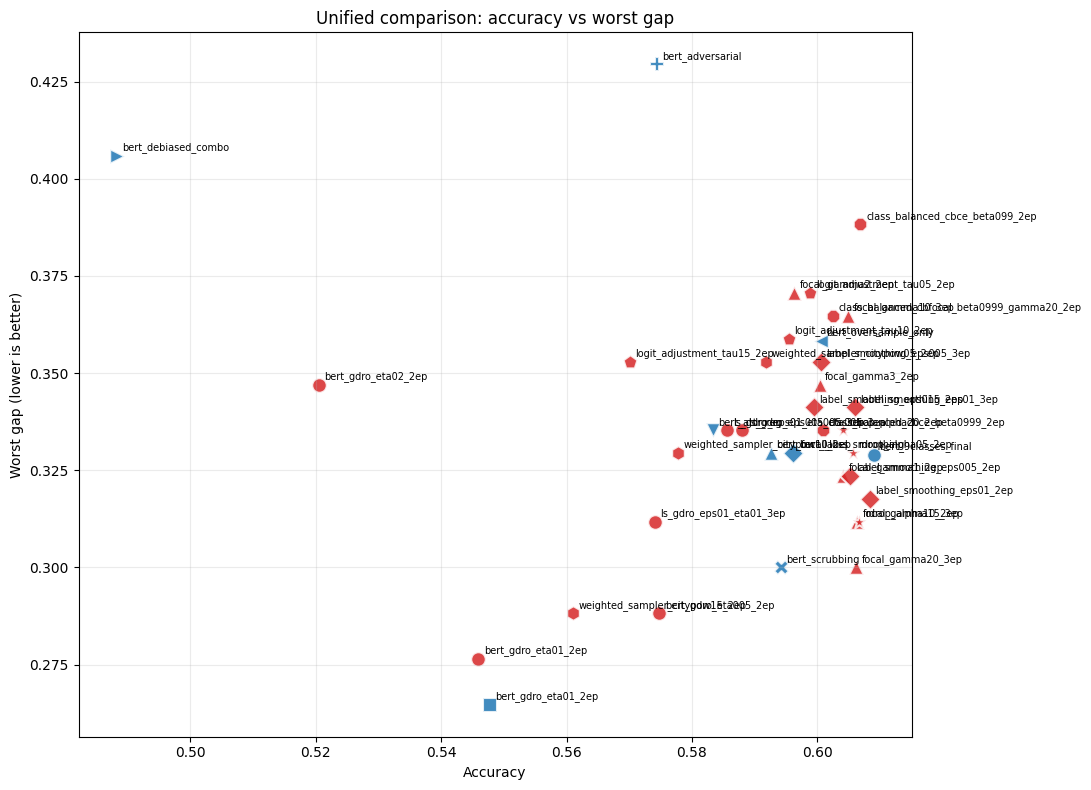

Saved plot to: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/results/unified_comparison/c71_accuracy_vs_gap.png


In [36]:
if plt is None:
    print('matplotlib not installed; skipping plot')
else:
    plot_df = unified_df.dropna(subset=['accuracy', 'worst_gap']).copy()
    if plot_df.empty:
        print('No rows with both accuracy and worst_gap available')
    else:
        colors = {'main': '#1f77b4', 'challenger': '#d62728'}
        markers = {'baseline': 'o', 'groupdro': 's', 'focal': '^', 'label_smoothing': 'D', 'adversarial': 'P', 'scrubbing': 'X', 'attr_reg': 'v', 'oversampling': '<', 'combined': '>', 'weighted_sampler': 'h', 'rdrop': '*', 'class_balanced': '8', 'logit_adjustment': 'p', 'other': 'o'}
        fig, ax = plt.subplots(figsize=(11, 8))
        for _, row in plot_df.iterrows():
            ax.scatter(row['accuracy'], row['worst_gap'], c=colors.get(row['track'], 'gray'), marker=markers.get(row['family_group'], 'o'), s=110, alpha=0.85, edgecolors='white', linewidths=1.5)
            ax.annotate(row['model_name'], (row['accuracy'], row['worst_gap']), fontsize=7, xytext=(4, 4), textcoords='offset points')
        ax.set_xlabel('Accuracy')
        ax.set_ylabel('Worst gap (lower is better)')
        ax.set_title('Unified comparison: accuracy vs worst gap')
        ax.grid(alpha=0.25)
        plt.tight_layout()
        plt.savefig(PLOT_PATH, dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved plot to:', PLOT_PATH)
